In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
import glob

# specify the directory and the criteria (e.g., file extension)
directory = 'models/temp'
criteria = 'progress_*.csv'  

# get a list of files that match the criteria
files = [f for f in glob.glob(os.path.join(directory, criteria))]
df_list = [pd.read_csv(f) for f in sorted(files)]


In [21]:
dfx = pd.read_csv("models/temp/progress_1.csv")


In [24]:
df_list.append(dfx)
df = pd.concat(df_list)
df = df.reset_index(drop=True)


In [27]:
dfx.columns

Index(['rollout/ep_len_mean', 'time/time_elapsed', 'time/total_timesteps',
       'rollout/ep_rew_mean', 'time/fps', 'time/iterations', 'train/loss',
       'train/n_updates', 'train/value_loss', 'train/clip_range',
       'train/approx_kl', 'train/learning_rate', 'train/clip_fraction',
       'train/explained_variance', 'train/entropy_loss',
       'train/policy_gradient_loss', 'black_wins'],
      dtype='object')

In [28]:
def plot_value(dfx, val):
    bw = dfx[val]
    bw[~bw.isnull()].plot()

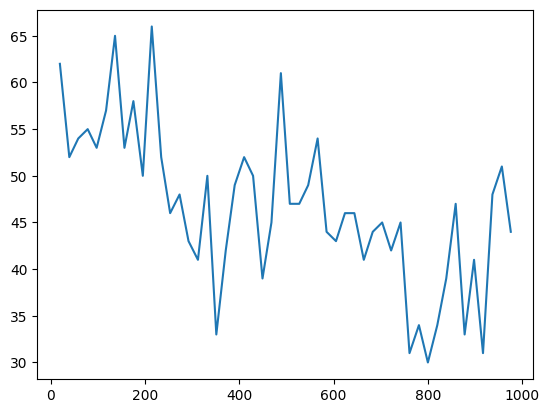

In [29]:
plot_value(dfx, "black_wins")

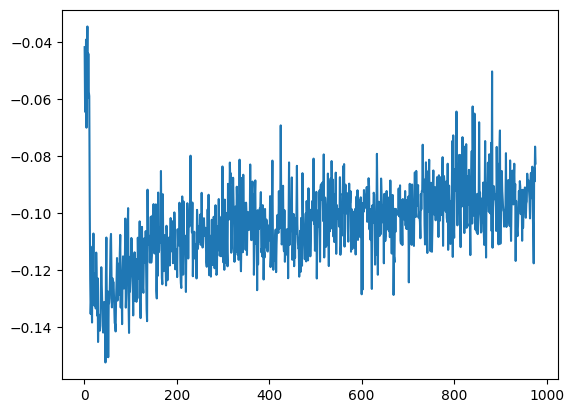

In [30]:
plot_value(dfx, "train/loss")

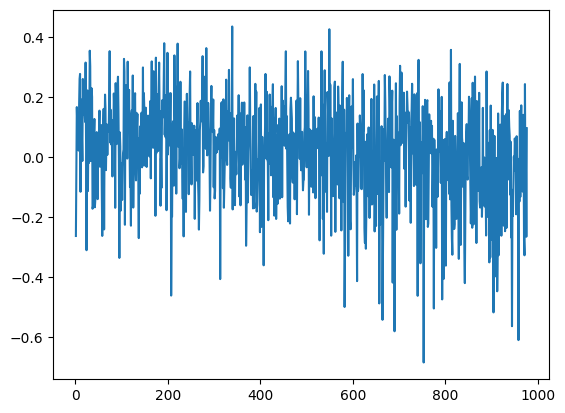

In [31]:
plot_value(dfx, "train/explained_variance")

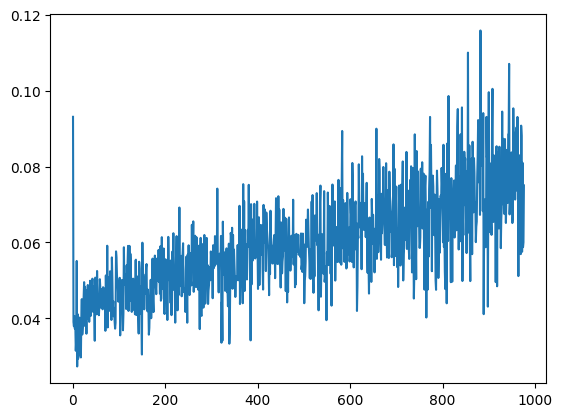

In [32]:
plot_value(dfx, "train/value_loss")

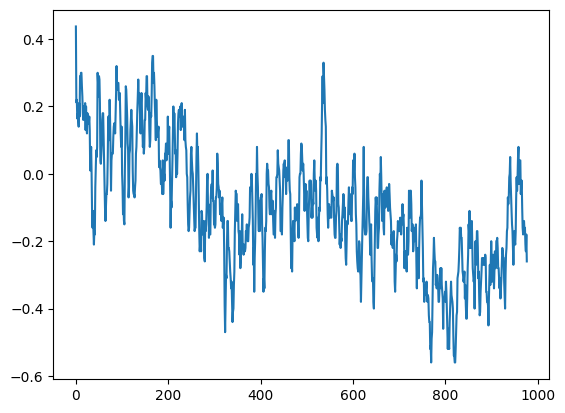

In [33]:
plot_value(dfx, "rollout/ep_rew_mean")

In [ ]:
# df.to_csv("models/temp/results_5_layer_0003LR_ppo_512.csv")

In [17]:
len(df)

2931

In [13]:
df["train/loss"][2000:]

2000   -0.106239
2001   -0.116699
2002   -0.115919
2003   -0.088279
2004   -0.095802
          ...   
2926   -0.120625
2927   -0.130864
2928   -0.111332
2929   -0.122500
2930   -0.104059
Name: train/loss, Length: 931, dtype: float64

In [18]:
x = range(2000,len(df))

In [19]:
def slope(x, y):
    mx = np.mean(x)
    my = np.mean(y)
    numerator = sum((x - mx) * (y - my))
    denom = sum((x - mx) ** 2)
    return numerator / denom

In [20]:
slope(x, df["train/loss"][2000:])

-6.791404334026066e-06